# 01. 데이터 로드와 수익률 계산

- 가격 패널 로드: `data/raw/prices.csv` 가 있으면 사용, 없으면 synthetic price panel 생성
- `tau = 1..20` 수익률 계산: `r_i,tau(t) = (p_i(t) - p_i(t-tau)) / p_i(t-tau)`
- cross-section 표준편차 정규화: `r_dagger_tau(t) = r_tau(t) / sigma_tau(t)`
- processed 데이터 저장

**실데이터 교체 방법**: `data/raw/prices.csv` 에 `date, asset, close` long format CSV를 두면
synthetic 대신 해당 데이터를 사용한다.

In [1]:
# 공통 설정 (00_environment_check.ipynb 와 동일)
from pathlib import Path
import random
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

ROOT = Path("..").resolve()
DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
SAMPLE_DIR = DATA_DIR / "sample"
REPORT_DIR = ROOT / "reports"
FIG_DIR = REPORT_DIR / "figures"
RESULT_DIR = REPORT_DIR / "results"
for p in [RAW_DIR, PROCESSED_DIR, SAMPLE_DIR, FIG_DIR, RESULT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cuda


## Cell 1: CSV 로드 또는 synthetic price panel 생성

synthetic panel은 팩터 구조(시장 팩터 + 스타일 팩터)에 AR(1) 평균회귀 미스프라이싱 항을 더해
논문이 가정하는 "잔차 = 미스프라이싱 → 이후 보정" 구조를 재현할 수 있게 설계했다.

In [2]:
def generate_synthetic_prices(
    n_assets=100,
    n_days=3000,
    n_factors=5,
    seed=42,
    factor_vol=0.010,
    idio_vol=0.012,
    mispricing_vol=0.009,
    mispricing_rho=0.95,
    drift=0.0002,
    start="2010-01-04",
    asset_names=None,
):
    # 팩터 구조 + 평균회귀 미스프라이싱을 갖는 synthetic price panel.
    # log(p_it) = drift 누적 + (B f_t) 누적 + idio 누적 + m_it
    # m_it 은 AR(1) 평균회귀 -> 양(+)의 abnormal return 이후 반대 방향 수익률이 나오도록 설계
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(start, periods=n_days)
    if asset_names is None:
        asset_names = [f"A{i:03d}" for i in range(n_assets)]
    assert len(asset_names) == n_assets

    # 팩터 로딩: 첫 팩터는 시장 팩터(로딩 평균 1), 나머지는 스타일 팩터
    B = np.zeros((n_assets, n_factors))
    B[:, 0] = rng.normal(1.0, 0.3, n_assets)
    if n_factors > 1:
        B[:, 1:] = rng.normal(0.0, 0.5, (n_assets, n_factors - 1))

    f_vol = np.full(n_factors, factor_vol * 0.5)
    f_vol[0] = factor_vol
    f = rng.normal(0.0, 1.0, (n_days, n_factors)) * f_vol

    idio = rng.normal(0.0, idio_vol, (n_days, n_assets))

    eta = rng.normal(0.0, mispricing_vol, (n_days, n_assets))
    m = np.zeros((n_days, n_assets))
    for t in range(1, n_days):
        m[t] = mispricing_rho * m[t - 1] + eta[t]

    fundamental = drift + f @ B.T + idio          # 일간 log 수익률(펀더멘털)
    log_price = np.cumsum(fundamental, axis=0) + m
    prices = 100.0 * np.exp(log_price)
    return pd.DataFrame(prices, index=dates, columns=asset_names)

In [3]:
RAW_CSV = RAW_DIR / "prices.csv"

if RAW_CSV.exists():
    print("실데이터 사용:", RAW_CSV)
    long_df = pd.read_csv(RAW_CSV, parse_dates=["date"])
else:
    print("synthetic price panel 생성 (N=100, 3000 영업일)")
    prices_wide = generate_synthetic_prices(n_assets=100, n_days=3000, seed=SEED)
    long_df = (
        prices_wide.stack().rename("close").rename_axis(["date", "asset"]).reset_index()
    )
    long_df.head(1000).to_csv(SAMPLE_DIR / "synthetic_prices_sample.csv", index=False)

long_df.head()

synthetic price panel 생성 (N=100, 3000 영업일)


,date,asset,close
0,2010-01-04,A000,102.066197
1,2010-01-04,A001,102.624041
2,2010-01-04,A002,102.391575
3,2010-01-04,A003,103.445879
4,2010-01-04,A004,101.262623


## Cell 2: long format → wide matrix (index: date, columns: asset)

In [4]:
prices = long_df.pivot(index="date", columns="asset", values="close").sort_index()
print("shape:", prices.shape)
prices.iloc[:3, :5]

shape: (3000, 100)


asset,A000,A001,A002,A003,A004
date,,,,,
2010-01-04,102.066197,102.624041,102.391575,103.445879,101.262623
2010-01-05,102.239212,99.679447,103.463150,101.850494,99.553469
2010-01-06,99.615809,96.940052,99.762732,101.360328,97.482274


## Cell 3: 수익률 / 정규화 함수

In [5]:
def compute_returns(prices: pd.DataFrame, tau: int) -> pd.DataFrame:
    # r_i,tau(t) = (p_i(t) - p_i(t - tau)) / p_i(t - tau)
    return prices.pct_change(periods=tau)


def cross_section_scale(returns: pd.DataFrame) -> pd.Series:
    # sigma_tau(t) = std({r_i,tau(t) | i = 1..N})
    scale = returns.std(axis=1, skipna=True)
    return scale.replace(0, np.nan)


def normalize_returns(returns: pd.DataFrame, scale: pd.Series = None) -> pd.DataFrame:
    # r_dagger_tau(t) = r_tau(t) / sigma_tau(t)
    if scale is None:
        scale = cross_section_scale(returns)
    return returns.div(scale, axis=0)

## Cell 4: tau별 수익률 dict 생성 (tau = 1..20)

In [6]:
TAU_MAX = 20  # 주식 실험의 목표 타임스케일 (tau_star = 20)

returns_by_tau = {tau: compute_returns(prices, tau) for tau in range(1, TAU_MAX + 1)}

# 수식 검증: pct_change(tau) == (p(t) - p(t-tau)) / p(t-tau)
t_chk, a_chk, tau_chk = 100, prices.columns[0], 5
manual = prices.iloc[t_chk][a_chk] / prices.iloc[t_chk - tau_chk][a_chk] - 1
assert abs(returns_by_tau[tau_chk].iloc[t_chk][a_chk] - manual) < 1e-12
print("수익률 수식 검증 통과")
returns_by_tau[1].iloc[1:4, :4]

수익률 수식 검증 통과


asset,A000,A001,A002,A003
date,,,,
2010-01-05,0.001695,-0.028693,0.010465,-0.015422
2010-01-06,-0.025659,-0.027482,-0.035766,-0.004813
2010-01-07,0.013930,-0.039113,0.021108,0.010324


## Cell 5: cross-section 정규화

In [7]:
sigma_by_tau = {tau: cross_section_scale(r) for tau, r in returns_by_tau.items()}
norm_by_tau = {tau: normalize_returns(r, sigma_by_tau[tau]) for tau, r in returns_by_tau.items()}

# 정규화 후 각 날짜의 cross-section std 는 1
chk = norm_by_tau[20].iloc[100:110].std(axis=1)
assert np.allclose(chk, 1.0)
print("정규화 검증 통과 (cross-section std = 1)")

정규화 검증 통과 (cross-section std = 1)


## Cell 6: 결측치 현황과 샘플 그래프

결측치 수 (앞부분 tau개 시점의 구조적 NaN 포함):
1      100
5      500
20    2000
dtype: int64


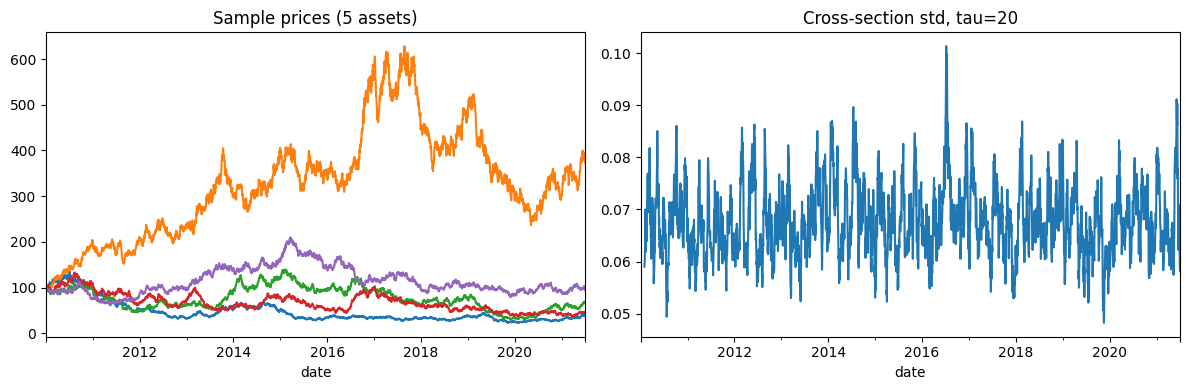

In [8]:
na_counts = pd.Series(
    {tau: int(returns_by_tau[tau].isna().sum().sum()) for tau in [1, 5, 20]}
)
print("결측치 수 (앞부분 tau개 시점의 구조적 NaN 포함):")
print(na_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
prices.iloc[:, :5].plot(ax=axes[0], legend=False, title="Sample prices (5 assets)")
sigma_by_tau[20].plot(ax=axes[1], title="Cross-section std, tau=20")
plt.tight_layout()
plt.savefig(FIG_DIR / "data_overview.png", dpi=120)
plt.show()

## Cell 7: processed 데이터 저장

In [9]:
panel = {
    "prices": prices,
    "returns_by_tau": {t: df.astype(np.float32) for t, df in returns_by_tau.items()},
    "norm_by_tau": {t: df.astype(np.float32) for t, df in norm_by_tau.items()},
    "sigma_by_tau": sigma_by_tau,
}
with open(PROCESSED_DIR / "stock_panel.pkl", "wb") as fh:
    pickle.dump(panel, fh)
print("saved:", PROCESSED_DIR / "stock_panel.pkl")

saved: C:\Users\wodlf\OneDrive\Desktop\논문 구현\data\processed\stock_panel.pkl
